In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

In [2]:
df = pd.read_csv('14-income_evaluation.csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [5]:
df.columns = ['age', 'workclass', 'finalweight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   finalweight     32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
categorical = [col for col in df.columns if df[col].dtype == 'O']
numerical = [col for col in df.columns if df[col].dtype != 'O'] 
df[categorical]

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...
32556,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,United-States,<=50K
32557,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,>50K
32558,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K
32559,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,United-States,<=50K


In [8]:
df[numerical]

,age,finalweight,education-num,capital-gain,capital-loss,hours-per-week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40
...,...,...,...,...,...,...
32556,27,257302,12,0,0,38
32557,40,154374,9,0,0,40
32558,58,151910,9,0,0,40
32559,22,201490,9,0,0,20


In [9]:
for col in categorical : 
    print('\n' , df[col].value_counts())


 workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

 education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

 marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

 occupation
Prof-specialty       4140
Craft-repair         4099
Exec-manageri

In [10]:
df.head()

,age,workclass,finalweight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


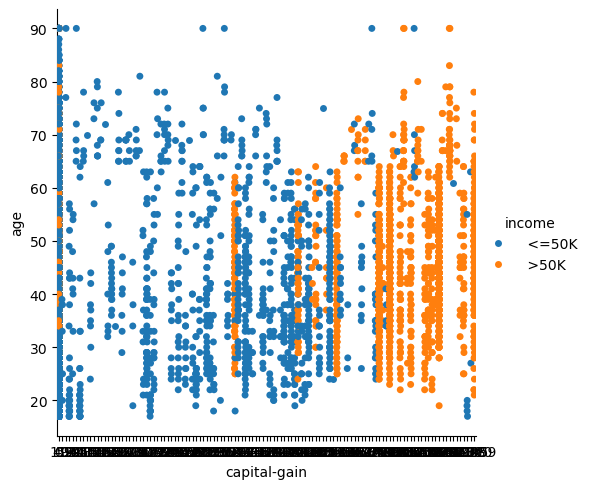

In [11]:
sns.catplot(data = df , x = 'capital-gain' , y = 'age' , hue = 'income')
plt.show()

<Axes: xlabel='race', ylabel='count'>

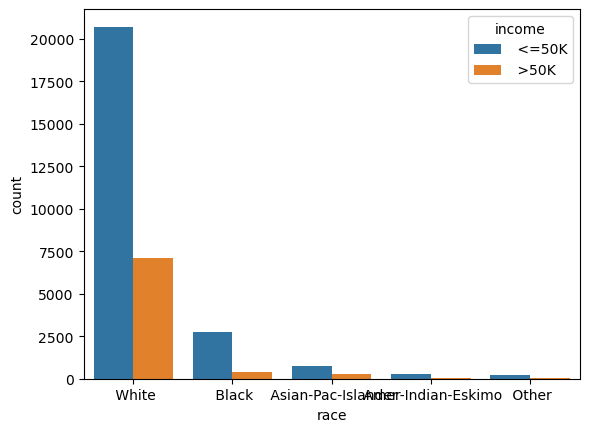

In [12]:
sns.countplot(data = df  , x = 'race' , hue = 'income')

<Axes: xlabel='sex', ylabel='education-num'>

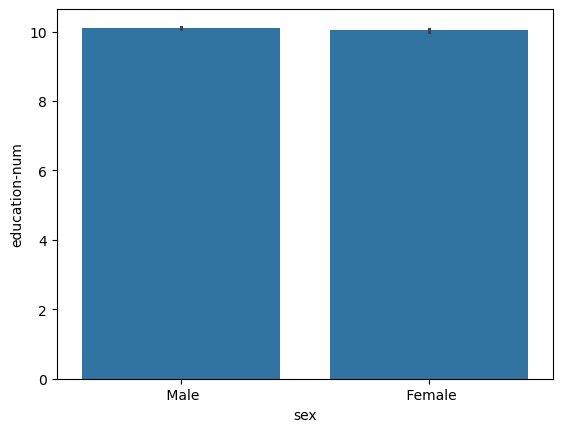

In [13]:
sns.barplot(data = df , y = 'education-num'  , x = 'sex')

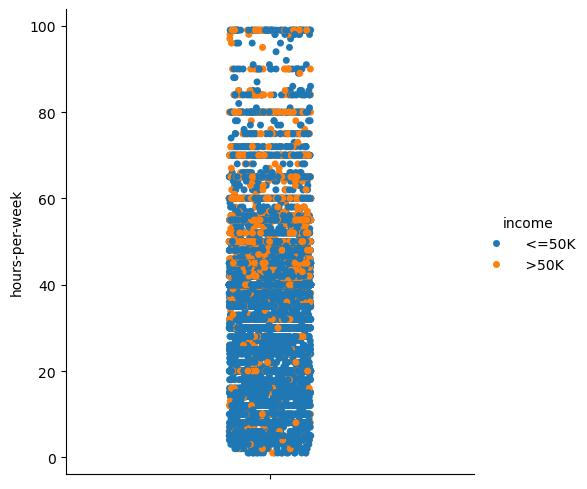

In [14]:
sns.catplot(data = df , y = 'hours-per-week' , hue = 'income')

<Axes: xlabel='education-num', ylabel='count'>

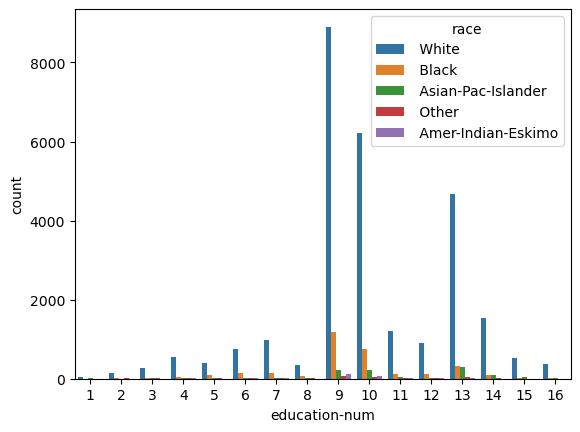

In [15]:
sns.countplot(data = df , x = 'education-num' , hue = 'race'  )

In [16]:
for col in df[['native-country' , 'occupation' , 'workclass']] : 
    df[col] = df[col].replace(' ?' , np.nan)

In [17]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = 'income' , axis = 1 )
y = df['income']
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 15)
X_train.head()

,age,workclass,finalweight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
32174,44,Self-emp-not-inc,157217,Bachelors,13,Never-married,Sales,Not-in-family,White,Male,0,0,42,United-States
2680,26,Local-gov,336969,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,28,El-Salvador
10874,53,Private,233369,Some-college,10,Widowed,Exec-managerial,Unmarried,White,Female,0,0,40,United-States
25028,30,Private,348618,9th,5,Married-civ-spouse,Craft-repair,Husband,Other,Male,0,0,40,Mexico
25881,50,Self-emp-inc,140516,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States


In [19]:
X_train.isnull().sum()

age                  0
workclass         1262
finalweight          0
education            0
education-num        0
marital-status       0
occupation        1265
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     392
dtype: int64

In [20]:
X_train['workclass'].mode()[0]

' Private'

In [21]:
for i in ['workclass' , 'occupation', 'native-country'] : 
    for splits in [X_train , X_test] : 
        splits[i] = splits[i].fillna(X_train[i].mode()[0])

In [22]:
X_test.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

In [23]:
# Encoding 

In [24]:
# Target encoding for native-country column

In [25]:
y_train_binary = y_train.apply(lambda x : 1 if x.strip() == '>50K' else 0 )
y_train_binary.value_counts()

income
0    17276
1     5516
Name: count, dtype: int64

In [26]:
target_means = y_train_binary.groupby(X_train['native-country']).mean()

In [27]:
for i in [X_train , X_test] : 
    i['native-country-encoded'] = i['native-country'].map(target_means)
    i['native-country-encoded'] = i['native-country-encoded'].fillna(y_train_binary.mean())

In [28]:
X_test.drop(columns = 'native-country' , axis = 1  , inplace = True)
X_train.drop(columns = 'native-country' , axis = 1  , inplace = True)

In [29]:
X_train.head()

,age,workclass,finalweight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country-encoded
32174,44,Self-emp-not-inc,157217,Bachelors,13,Never-married,Sales,Not-in-family,White,Male,0,0,42,0.247311
2680,26,Local-gov,336969,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,28,0.129032
10874,53,Private,233369,Some-college,10,Widowed,Exec-managerial,Unmarried,White,Female,0,0,40,0.247311
25028,30,Private,348618,9th,5,Married-civ-spouse,Craft-repair,Husband,Other,Male,0,0,40,0.062907
25881,50,Self-emp-inc,140516,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,0.247311


In [30]:
one_hot_column = [
    'workclass', 
    'marital-status', 
    'occupation', 
    'relationship', 
    'race', 
    'sex'
]

X_train_enc = pd.get_dummies(data = X_train , columns = one_hot_column , drop_first = True , dtype = int)
X_test_enc = pd.get_dummies(data = X_test , columns = one_hot_column , drop_first = True , dtype = int)

In [31]:
X_train_enc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22792 entries, 32174 to 7624
Data columns (total 44 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    22792 non-null  int64  
 1   finalweight                            22792 non-null  int64  
 2   education                              22792 non-null  object 
 3   education-num                          22792 non-null  int64  
 4   capital-gain                           22792 non-null  int64  
 5   capital-loss                           22792 non-null  int64  
 6   hours-per-week                         22792 non-null  int64  
 7   native-country-encoded                 22792 non-null  float64
 8   workclass_ Local-gov                   22792 non-null  int64  
 9   workclass_ Never-worked                22792 non-null  int64  
 10  workclass_ Private                     22792 non-null  int64  
 11  work

In [32]:
# Random forest algoritmasında scale kullanmasak da olur ancak başka eğitim modellerindede makine eğitilecekse scale edilmelidir 

In [33]:
X_test_enc.head()

,age,finalweight,education,education-num,capital-gain,capital-loss,hours-per-week,native-country-encoded,workclass_ Local-gov,workclass_ Never-worked,...,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male
10125,47,182752,HS-grad,9,0,0,35,0.423077,0,0,...,0,0,0,0,1,0,0,0,1,0
11478,73,161027,5th-6th,3,0,0,20,0.247311,1,0,...,0,0,0,0,0,0,0,0,1,1
4224,18,152182,Some-college,10,0,0,25,0.247311,0,0,...,0,0,1,0,0,0,0,0,1,0
6592,66,284021,HS-grad,9,0,0,40,0.247311,0,0,...,1,0,0,0,0,0,0,0,1,0
21910,39,261504,12th,8,0,0,40,0.247311,0,0,...,0,0,0,1,0,0,0,0,1,0


In [34]:
X_train_enc.columns

Index(['age', 'finalweight', 'education', 'education-num', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country-encoded',
       'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay',
       'marital-status_ Married-AF-spouse',
       'marital-status_ Married-civ-spouse',
       'marital-status_ Married-spouse-absent',
       'marital-status_ Never-married', 'marital-status_ Separated',
       'marital-status_ Widowed', 'occupation_ Armed-Forces',
       'occupation_ Craft-repair', 'occupation_ Exec-managerial',
       'occupation_ Farming-fishing', 'occupation_ Handlers-cleaners',
       'occupation_ Machine-op-inspct', 'occupation_ Other-service',
       'occupation_ Priv-house-serv', 'occupation_ Prof-specialty',
       'occupation_ Protective-serv', 'occupation_ Sales',
       'occupation_ Tech-support', 'occupation_ Transpo

In [35]:
from sklearn.preprocessing import RobustScaler
X_train_enc.drop(columns = 'education' , axis = 1 , inplace = True)
X_test_enc.drop(columns = 'education' , axis = 1 , inplace = True)
scaler = RobustScaler()

X_train_enc = scaler.fit_transform(X_train_enc)
X_test_enc = scaler.transform(X_test_enc)


In [36]:
# Array'i DataFrame'e çevir
X_train_df = pd.DataFrame(X_train_enc)
X_test_df = pd.DataFrame(X_test_enc)
# Şimdi head çalışır
X_train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0.35,-0.175622,1.000000,0.0,0.0,0.4,0.000000,0.0,0.0,-1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.55,1.335801,1.000000,0.0,0.0,-2.4,-0.118279,1.0,0.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.80,0.464693,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.0
3,-0.35,1.433750,-1.666667,0.0,0.0,0.0,-0.184405,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0
4,0.65,-0.316050,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rfc = RandomForestClassifier(n_estimators = 10 , n_jobs = -1 , random_state = 15 )
rfc.fit(X_train_df , y_train)

RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=15)

In [39]:
y_pred = rfc.predict(X_test_df) 
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print('Accuracy : ' , accuracy_score(y_test , y_pred))
print('Confusion Matrix : ' , confusion_matrix(y_test , y_pred))
print('Classification Report : ' , classification_report(y_test , y_pred))

Accuracy :  0.8537209540382844
Confusion Matrix :  [[6959  485]
 [ 944 1381]]
Classification Report :                precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7444
        >50K       0.74      0.59      0.66      2325

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



In [40]:
rfc = RandomForestClassifier(n_estimators = 100 , n_jobs = -1 , random_state = 15 )
rfc.fit(X_train_df , y_train)
y_pred = rfc.predict(X_test_df) 
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print('Accuracy : ' , accuracy_score(y_test , y_pred))
print('Confusion Matrix : ' , confusion_matrix(y_test , y_pred))
print('Classification Report : ' , classification_report(y_test , y_pred))

Accuracy :  0.8627290408434845
Confusion Matrix :  [[6945  499]
 [ 842 1483]]
Classification Report :                precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7444
        >50K       0.75      0.64      0.69      2325

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [41]:
rfc = RandomForestClassifier()
rf_params = {
    'n_estimators' : [100 , 200 , 300 , 500 , 1000],
    'max_depth' : [5 , 10 , 8 , None],
    'max_features' : ['log2' , 'sqrt' , 5 , 10 , None]
}
from sklearn.model_selection import RandomizedSearchCV

In [42]:
random = RandomizedSearchCV(estimator = rfc , param_distributions = rf_params ,
                            cv = 5 , scoring = 'accuracy' , n_jobs = -1                            
                           )
random.fit(X_train_df , y_train)
y_pred = random.predict(X_test_df) 
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print('Accuracy : ' , accuracy_score(y_test , y_pred))
print('Confusion Matrix : ' , confusion_matrix(y_test , y_pred))
print('Classification Report : ' , classification_report(y_test , y_pred))

Accuracy :  0.8629337700890573
Confusion Matrix :  [[7054  390]
 [ 949 1376]]
Classification Report :                precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7444
        >50K       0.78      0.59      0.67      2325

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.79      9769
weighted avg       0.86      0.86      0.86      9769



In [43]:

print('Accuracy : ' , accuracy_score(y_test , y_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , y_pred))
print('Classification Report\n : ' , classification_report(y_test , y_pred))

Accuracy :  0.8629337700890573
Confusion Matrix : 
 [[7054  390]
 [ 949 1376]]
Classification Report
 :                precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7444
        >50K       0.78      0.59      0.67      2325

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.79      9769
weighted avg       0.86      0.86      0.86      9769

